# TikTok Video Engagement: Exploratory Data Analysis

## Project overview

This project explores an **educational TikTok dataset provided through Google/Coursera coursework**. The goal is to identify patterns that distinguish videos labeled as **claims** from videos labeled as **opinions**, with a focus on engagement behavior, account status, data quality, and outliers.

### Business question
**Which characteristics and engagement patterns appear to distinguish claim videos from opinion videos?**

### Tools
Python · Pandas · NumPy · Matplotlib · Jupyter Notebook

### Analysis workflow
1. Inspect dataset structure and data quality
2. Examine descriptive statistics and distributions
3. Compare claims and opinions
4. Explore verification and author-ban status
5. Identify high-value outliers
6. Examine relationships among engagement metrics
7. Extend the course analysis with engagement-rate features

> **Portfolio note:** The original analysis began as a Coursera lab. This version has been reorganized as a portfolio case study and includes an additional independent engagement-rate analysis.


## 1. Setup and data loading

The dataset contains video-level attributes such as duration, verification status, author ban status, views, likes, shares, downloads, comments, and the target label `claim_status`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("data/tiktok_dataset.csv")
if not data_path.exists():
    data_path = Path("tiktok_dataset.csv")

data = pd.read_csv(data_path)
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")

Dataset shape: 19,382 rows × 12 columns


In [2]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


## 2. Data inspection and quality checks

I first reviewed the dataset dimensions, column types, missing values, and descriptive statistics. Missingness is concentrated in `claim_status`, transcription text, and the engagement-count columns.


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [4]:
missing = data.isna().sum().sort_values(ascending=False)
missing[missing > 0]

claim_status                298
video_share_count           298
video_view_count            298
video_transcription_text    298
video_download_count        298
video_comment_count         298
video_like_count            298
dtype: int64

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
#,19382.0,9.691500e+03,5.595246e+03,1.000000e+00,4.846250e+03,9.691500e+03,1.453675e+04,1.938200e+04
video_id,19382.0,5.627454e+09,2.536440e+09,1.234959e+09,3.430417e+09,5.618664e+09,7.843960e+09,9.999873e+09
video_duration_sec,19382.0,3.242173e+01,1.622997e+01,5.000000e+00,1.800000e+01,3.200000e+01,4.700000e+01,6.000000e+01
video_view_count,19084.0,2.547086e+05,3.228933e+05,2.000000e+01,4.942500e+03,9.954500e+03,5.043270e+05,9.998170e+05
video_like_count,19084.0,8.430464e+04,1.334205e+05,0.000000e+00,8.107500e+02,3.403500e+03,1.250200e+05,6.578300e+05
video_share_count,19084.0,1.673525e+04,3.203617e+04,0.000000e+00,1.150000e+02,7.170000e+02,1.822200e+04,2.561300e+05
video_download_count,19084.0,1.049430e+03,2.004300e+03,0.000000e+00,7.000000e+00,4.600000e+01,1.156250e+03,1.499400e+04
video_comment_count,19084.0,3.493121e+02,7.996389e+02,0.000000e+00,1.000000e+00,9.000000e+00,2.920000e+02,9.599000e+03


In [6]:
data['claim_status'].value_counts(dropna=False)

claim_status
claim      9608
opinion    9476
NaN         298
Name: count, dtype: int64

### Data-quality observations

- The dataset contains **19,382 records and 12 columns**.
- `claim_status` is missing for 298 rows; the same number of records also lack the main engagement metrics.
- Among labeled records, claims and opinions are close to evenly represented, which makes direct comparison more meaningful.
- Engagement variables have large gaps between their medians and maximum values, suggesting strong right-skew and high-engagement observations.


## 3. Distribution analysis

Boxplots and histograms help show the spread, skew, and presence of extreme values in the main numeric variables.


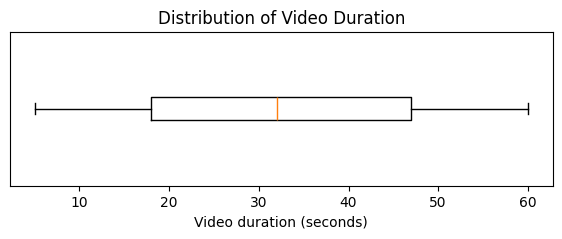

In [7]:
plt.figure(figsize=(7, 2))
plt.boxplot(data['video_duration_sec'].dropna(), vert=False)
plt.title('Distribution of Video Duration')
plt.xlabel('Video duration (seconds)')
plt.yticks([])
plt.show()

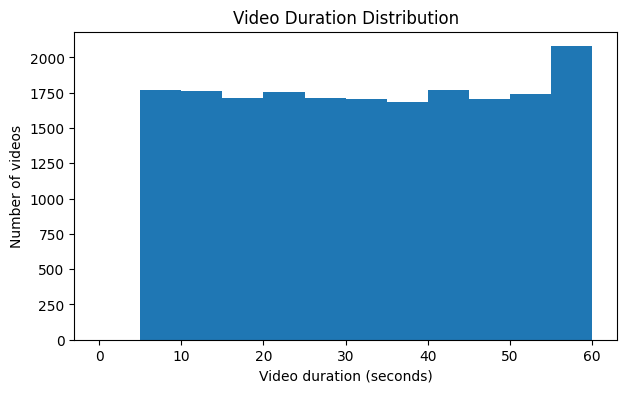

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(data['video_duration_sec'].dropna(), bins=range(0, 61, 5))
plt.title('Video Duration Distribution')
plt.xlabel('Video duration (seconds)')
plt.ylabel('Number of videos')
plt.show()

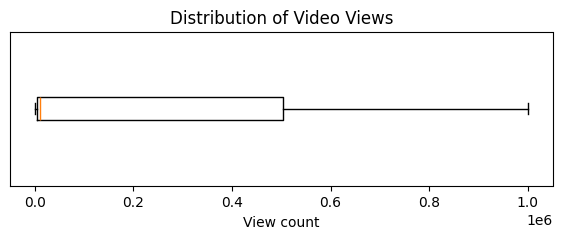

In [9]:
plt.figure(figsize=(7, 2))
plt.boxplot(data['video_view_count'].dropna(), vert=False)
plt.title('Distribution of Video Views')
plt.xlabel('View count')
plt.yticks([])
plt.show()

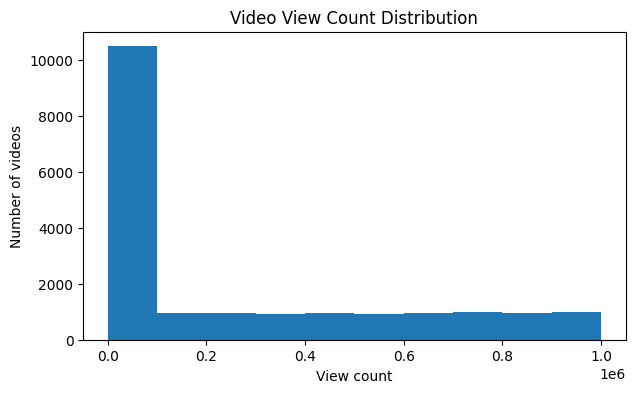

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(data['video_view_count'].dropna(), bins=range(0, 10**6 + 1, 10**5))
plt.title('Video View Count Distribution')
plt.xlabel('View count')
plt.ylabel('Number of videos')
plt.show()

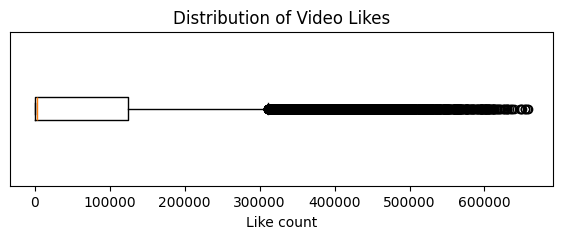

In [11]:
plt.figure(figsize=(7, 2))
plt.boxplot(data['video_like_count'].dropna(), vert=False)
plt.title('Distribution of Video Likes')
plt.xlabel('Like count')
plt.yticks([])
plt.show()

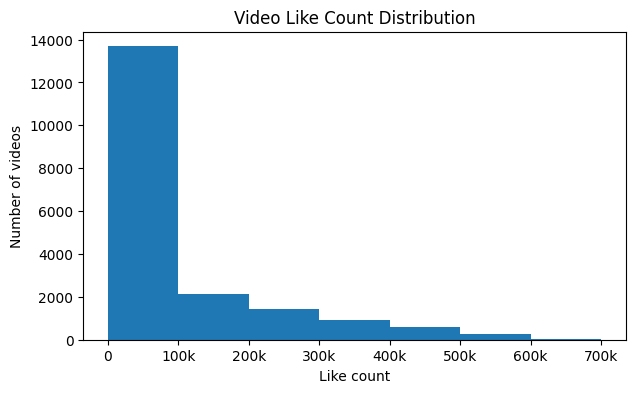

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(data['video_like_count'].dropna(), bins=range(0, 7 * 10**5 + 1, 10**5))
ticks = range(0, 7 * 10**5 + 1, 10**5)
labels = ['0'] + [f'{i}k' for i in range(100, 701, 100)]
plt.xticks(ticks, labels)
plt.title('Video Like Count Distribution')
plt.xlabel('Like count')
plt.ylabel('Number of videos')
plt.show()

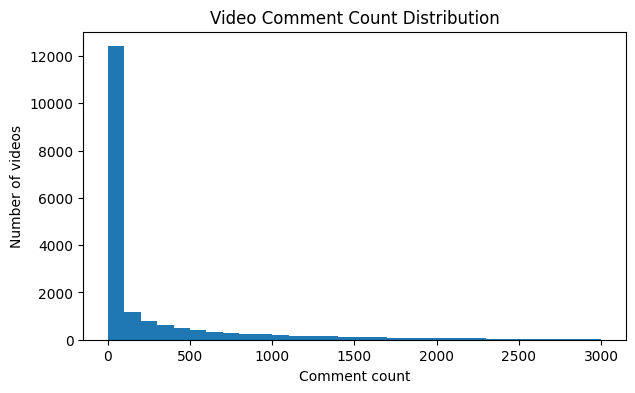

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(data['video_comment_count'].dropna(), bins=range(0, 3001, 100))
plt.title('Video Comment Count Distribution')
plt.xlabel('Comment count')
plt.ylabel('Number of videos')
plt.show()

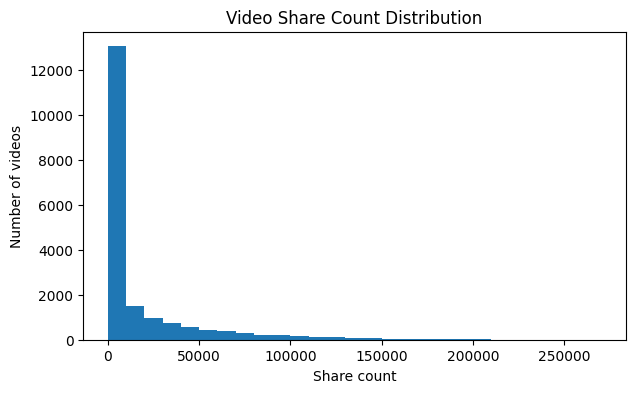

In [14]:
plt.figure(figsize=(7, 4))
plt.hist(data['video_share_count'].dropna(), bins=range(0, 270001, 10000))
plt.title('Video Share Count Distribution')
plt.xlabel('Share count')
plt.ylabel('Number of videos')
plt.show()

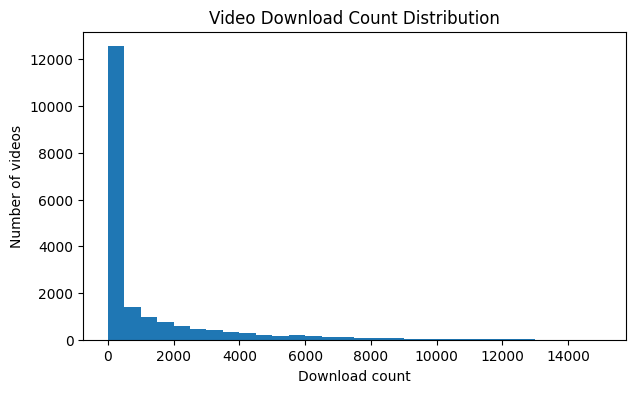

In [15]:
plt.figure(figsize=(7, 4))
plt.hist(data['video_download_count'].dropna(), bins=range(0, 15001, 500))
plt.title('Video Download Count Distribution')
plt.xlabel('Download count')
plt.ylabel('Number of videos')
plt.show()

### Distribution findings

Video duration is broadly spread across the available range, while engagement variables are strongly right-skewed. Most videos have relatively low engagement, but a smaller group of videos reaches very high view, like, share, download, and comment counts. This pattern is consistent with viral-content behavior and should be considered before treating high values as data errors.


## 4. Claim status, verification, and author status

Next, I compared claim/opinion labels with user verification and author-ban status to look for categorical patterns that may be useful in later classification modeling.


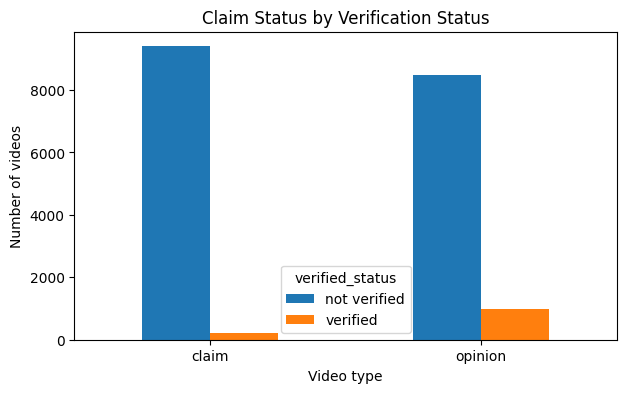

In [16]:
verification_counts = pd.crosstab(data['claim_status'], data['verified_status'])
verification_counts.plot(kind='bar', figsize=(7, 4))
plt.title('Claim Status by Verification Status')
plt.xlabel('Video type')
plt.ylabel('Number of videos')
plt.xticks(rotation=0)
plt.show()

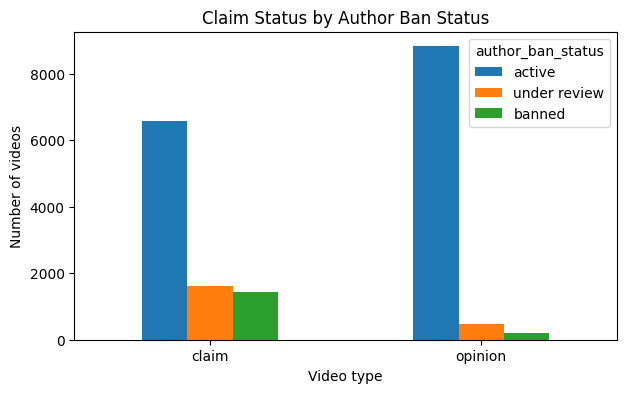

In [17]:
ban_counts = pd.crosstab(data['claim_status'], data['author_ban_status'])
ban_counts = ban_counts.reindex(columns=['active', 'under review', 'banned'])
ban_counts.plot(kind='bar', figsize=(7, 4))
plt.title('Claim Status by Author Ban Status')
plt.xlabel('Video type')
plt.ylabel('Number of videos')
plt.xticks(rotation=0)
plt.show()

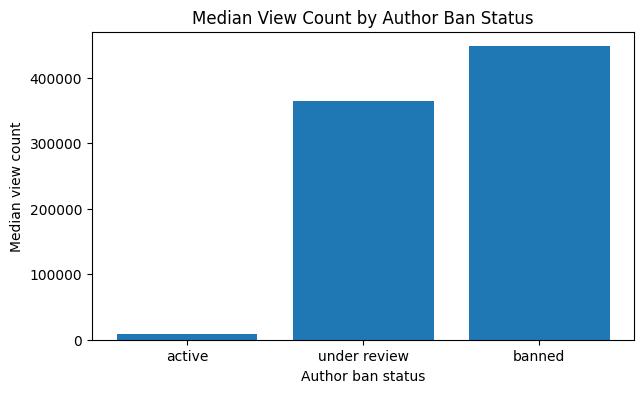

In [18]:
ban_status_medians = (
    data.groupby('author_ban_status')['video_view_count']
        .median()
        .reindex(['active', 'under review', 'banned'])
)

plt.figure(figsize=(7, 4))
plt.bar(ban_status_medians.index, ban_status_medians.values)
plt.title('Median View Count by Author Ban Status')
plt.xlabel('Author ban status')
plt.ylabel('Median view count')
plt.show()

## 5. Claim vs. opinion engagement

A central question is whether claim videos receive different levels of engagement from opinion videos.


In [19]:
median_views = data.groupby('claim_status')['video_view_count'].median()
median_views

claim_status
claim      501555.0
opinion      4953.0
Name: video_view_count, dtype: float64

In [20]:
view_summary = data.groupby('claim_status')['video_view_count'].agg(['count', 'median', 'mean', 'sum'])
view_summary['share_of_total_views'] = view_summary['sum'] / view_summary['sum'].sum()
view_summary

,count,median,mean,sum,share_of_total_views
claim_status,,,,,
claim,9608,501555.0,501029.452748,4.813891e+09,0.990338
opinion,9476,4953.0,4956.432250,4.696715e+07,0.009662


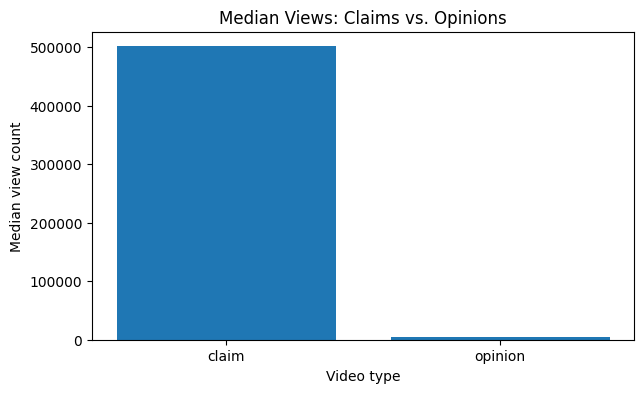

In [21]:
median_views = median_views.reindex(['claim', 'opinion'])

plt.figure(figsize=(7, 4))
plt.bar(median_views.index, median_views.values)
plt.title('Median Views: Claims vs. Opinions')
plt.xlabel('Video type')
plt.ylabel('Median view count')
plt.show()

### Key finding

The difference in median views is substantial:

- **Claim videos:** approximately **501,555 median views**
- **Opinion videos:** approximately **4,953 median views**

Claim videos therefore have roughly **101×** the median views of opinion videos in this dataset. They also account for about **99% of total views** among labeled records. This suggests that `video_view_count` may be a particularly informative feature for distinguishing the two classes.


## 6. Outlier analysis

Because the engagement variables are heavily right-skewed, I used the lab's modified threshold of:

**median + 1.5 × IQR**

The goal here is to quantify unusually high observations rather than automatically remove them. High engagement can be legitimate in social-media data.


In [22]:
count_cols = [
    'video_view_count',
    'video_like_count',
    'video_share_count',
    'video_download_count',
    'video_comment_count'
]

outlier_results = []

for column in count_cols:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    median = data[column].median()
    threshold = median + 1.5 * iqr
    outlier_count = (data[column] > threshold).sum()

    outlier_results.append({
        'variable': column,
        'threshold': threshold,
        'outlier_count': outlier_count
    })

pd.DataFrame(outlier_results)

,variable,threshold,outlier_count
0,video_view_count,759031.250,2343
1,video_like_count,189717.375,3468
2,video_share_count,27877.500,3732
3,video_download_count,1769.875,3733
4,video_comment_count,445.500,3882


### Outlier interpretation

The engagement variables contain thousands of observations above the selected threshold. I would **not automatically delete these values** because extreme engagement may reflect real viral behavior rather than measurement error. Their treatment should depend on the requirements and robustness of any future predictive model.


## 7. Relationship between views and likes

The scatterplot below explores the relationship between two major engagement variables and shows how observations separate by claim status.


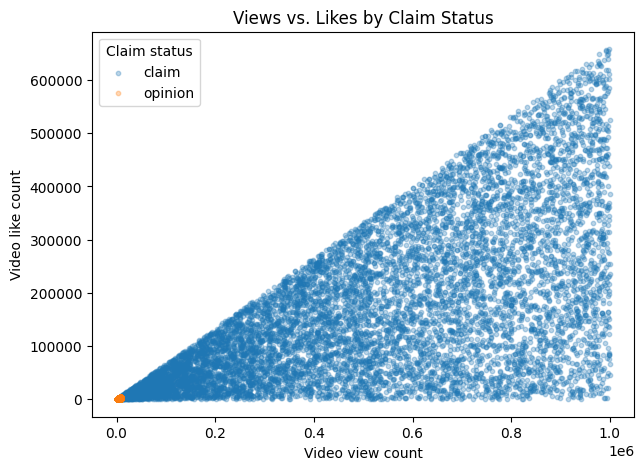

In [23]:
plt.figure(figsize=(7, 5))

for status, group in data.dropna(subset=['claim_status']).groupby('claim_status'):
    plt.scatter(
        group['video_view_count'],
        group['video_like_count'],
        s=10,
        alpha=0.3,
        label=status
    )

plt.title('Views vs. Likes by Claim Status')
plt.xlabel('Video view count')
plt.ylabel('Video like count')
plt.legend(title='Claim status')
plt.show()

## 8. Independent extension: engagement rates

Raw engagement counts can be dominated by view volume. To extend the original course analysis, I created engagement-rate features that normalize likes, comments, shares, and downloads by views.

This asks a different question: **Do claim videos simply reach more people, or do viewers also engage with them at different rates?**


In [24]:
rate_map = {
    'video_like_count': 'like_rate',
    'video_comment_count': 'comment_rate',
    'video_share_count': 'share_rate',
    'video_download_count': 'download_rate'
}

for count_col, rate_col in rate_map.items():
    data[rate_col] = np.where(
        data['video_view_count'] > 0,
        data[count_col] / data['video_view_count'],
        np.nan
    )

engagement_rates = (
    data.groupby('claim_status')[
        ['like_rate', 'comment_rate', 'share_rate', 'download_rate']
    ]
    .median()
)

engagement_rates

,like_rate,comment_rate,share_rate,download_rate
claim_status,,,,
claim,0.329734,0.000774,0.049673,0.003091
opinion,0.218127,0.000253,0.032487,0.001978


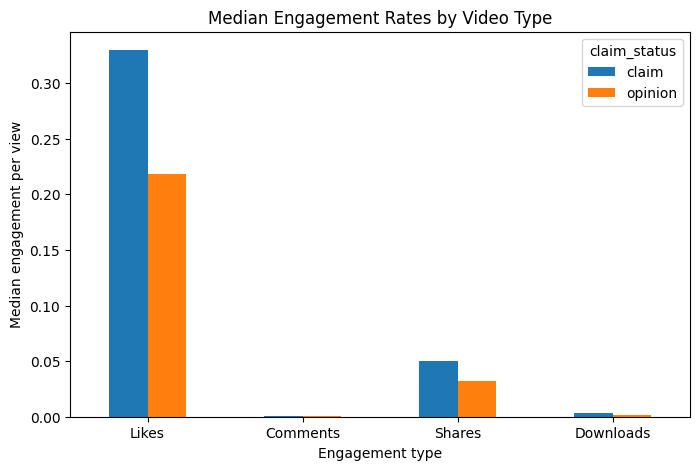

In [25]:
engagement_rates_plot = engagement_rates.T
engagement_rates_plot.index = ['Likes', 'Comments', 'Shares', 'Downloads']

engagement_rates_plot.plot(kind='bar', figsize=(8, 5))
plt.title('Median Engagement Rates by Video Type')
plt.xlabel('Engagement type')
plt.ylabel('Median engagement per view')
plt.xticks(rotation=0)
plt.show()

### Engagement-rate finding

The median normalized engagement rates are also higher for claim videos in this dataset. For example:

- Median like rate: about **33.0% for claims** vs. **21.8% for opinions**
- Median share rate: about **5.0% for claims** vs. **3.2% for opinions**

This suggests that the difference is not explained by reach alone: claim videos also tend to generate more engagement relative to their view counts.


## 9. Key findings

1. **Claims and opinions are nearly balanced among labeled records**, reducing concern that the major differences are simply caused by class size.
2. **Claim videos have dramatically higher reach:** median views are approximately 501K for claims versus 5K for opinions.
3. **Claim videos account for about 99% of total views** among labeled records.
4. **Author status differs substantially:** roughly 31.7% of claim-video authors are banned or under review, compared with about 7.0% of opinion-video authors.
5. **Engagement variables are heavily right-skewed**, with many high-value observations that may represent legitimate viral behavior.
6. **Normalized engagement rates are also higher for claims**, suggesting that claims differ from opinions in both reach and engagement intensity.

## 10. Conclusion and next steps

The exploratory analysis indicates that **view count, engagement metrics, and author status** may be useful predictors of `claim_status`. A logical next step would be to prepare the data for classification modeling and test whether these variables remain predictive when considered together.

Potential next steps:
- Handle missing values according to modeling requirements
- Encode categorical variables
- Examine multicollinearity among engagement features
- Build and compare classification models
- Evaluate model performance using precision, recall, F1 score, and a confusion matrix
- Investigate whether normalized engagement-rate features improve predictive performance

### Limitations

This is an educational dataset used for coursework. Findings should be interpreted as an analysis exercise and should not be generalized to TikTok's real production data or platform-wide behavior.
